# Advanced Quantum Kernel and Reservoir Models

This tutorial demonstrates the general-purpose QML APIs for advanced kernel models and fixed quantum reservoir models on synthetic datasets.

## Scope

The notebook is intentionally domain-neutral. Physics and mathematics examples live in `notebooks/real_examples/`; this tutorial focuses on reusable package APIs.

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
if repo_root.name == "tutorials":
    repo_root = repo_root.parents[1]
elif repo_root.name == "notebooks":
    repo_root = repo_root.parent

package_root = repo_root / "src"
if str(package_root) not in sys.path:
    sys.path.insert(0, str(package_root))

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from qml import (
    QuantumGaussianProcessRegressor,
    QuantumKernel,
    QuantumKernelPCA,
    QuantumOneClassClassifier,
    QuantumReservoirClassifier,
    QuantumReservoirFeatures,
    QuantumReservoirRegressor,
    TrainableQuantumKernelRegressor,
)
from qml.metrics import accuracy_score, mean_absolute_error, mean_squared_error
from qml.reporting import print_section


## Classification data

In [2]:
rng = np.random.default_rng(14)
x_cls, y_cls = make_blobs(
    n_samples=42,
    centers=2,
    n_features=2,
    cluster_std=1.2,
    random_state=14,
)
x_train_cls, x_test_cls, y_train_cls, y_test_cls = train_test_split(
    x_cls, y_cls, test_size=0.3, random_state=14, stratify=y_cls
)
cls_scaler = StandardScaler()
x_train_cls = cls_scaler.fit_transform(x_train_cls)
x_test_cls = cls_scaler.transform(x_test_cls)

print_section(
    "Classification dataset",
    [
        ("dataset", "two Gaussian blobs"),
        ("train_shape", list(x_train_cls.shape)),
        ("test_shape", list(x_test_cls.shape)),
        ("classes", sorted(np.unique(y_cls).tolist())),
    ],
)


Classification dataset
+-------------+--------------------+
| Metric      | Value              |
+-------------+--------------------+
| dataset     | two Gaussian blobs |
| train_shape | [29, 2]            |
| test_shape  | [13, 2]            |
| classes     | [0, 1]             |
+-------------+--------------------+



## Quantum kernel PCA and one-class detection

In [3]:
kernel = QuantumKernel(embedding="zz", seed=12)
kpca = QuantumKernelPCA(kernel, n_components=2)
z_train = kpca.fit_transform(x_train_cls)
z_test = kpca.transform(x_test_cls)

normal_train = x_train_cls[y_train_cls == 0]
detector = QuantumOneClassClassifier(QuantumKernel(embedding="zz", seed=13), nu=0.2)
detector.fit(normal_train)
one_class_pred = detector.predict(x_test_cls)
one_class_label = (one_class_pred == -1).astype(int)

unsupervised_results = {
    "kpca_component_count": int(z_train.shape[1]),
    "one_class_accuracy_against_class_1": accuracy_score(y_test_cls, one_class_label),
    "first_eigenvalue": float(kpca.eigenvalues_[0]),
}

print_section("Unsupervised kernel models", unsupervised_results.items())


Unsupervised kernel models
+------------------------------------+----------+
| Metric                             | Value    |
+------------------------------------+----------+
| kpca_component_count               | 2        |
| one_class_accuracy_against_class_1 | 0.846154 |
| first_eigenvalue                   | 11.1637  |
+------------------------------------+----------+



## Quantum reservoir classification

In [4]:
reservoir_clf = QuantumReservoirClassifier(
    QuantumReservoirFeatures(n_qubits=2, n_layers=2, seed=14),
    c=10.0,
)
reservoir_clf.fit(x_train_cls, y_train_cls)
res_cls_pred = reservoir_clf.predict(x_test_cls)

classification_results = {
    "quantum_reservoir_accuracy": accuracy_score(y_test_cls, res_cls_pred),
}

print_section("Reservoir classifier", classification_results.items())


Reservoir classifier
+----------------------------+-------+
| Metric                     | Value |
+----------------------------+-------+
| quantum_reservoir_accuracy | 1     |
+----------------------------+-------+



## Regression data

In [5]:
x_reg, y_reg = make_regression(
    n_samples=36,
    n_features=2,
    n_informative=2,
    noise=8.0,
    random_state=15,
)
y_reg = y_reg / np.std(y_reg)
x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(
    x_reg, y_reg, test_size=0.3, random_state=15
)
reg_scaler = StandardScaler()
x_train_reg = reg_scaler.fit_transform(x_train_reg)
x_test_reg = reg_scaler.transform(x_test_reg)

print_section(
    "Regression dataset",
    [
        ("dataset", "synthetic linear regression"),
        ("train_shape", list(x_train_reg.shape)),
        ("test_shape", list(x_test_reg.shape)),
    ],
)


Regression dataset
+-------------+-----------------------------+
| Metric      | Value                       |
+-------------+-----------------------------+
| dataset     | synthetic linear regression |
| train_shape | [25, 2]                     |
| test_shape  | [11, 2]                     |
+-------------+-----------------------------+



## Trainable kernels, quantum GPR, and reservoir regression

In [6]:
tqk = TrainableQuantumKernelRegressor(
    embedding="data_reupload",
    embedding_layers=1,
    steps=2,
    step_size=0.05,
    alpha=1e-3,
    seed=16,
)
tqk.fit(x_train_reg, y_train_reg)
tqk_pred = tqk.predict(x_test_reg)

qgpr = QuantumGaussianProcessRegressor(QuantumKernel(embedding="iqp", seed=17), alpha=1e-3)
qgpr.fit(x_train_reg, y_train_reg)
gpr_pred, gpr_std = qgpr.predict(x_test_reg, return_std=True)

reservoir_reg = QuantumReservoirRegressor(
    QuantumReservoirFeatures(n_qubits=2, n_layers=2, seed=18),
    alpha=1e-3,
)
reservoir_reg.fit(x_train_reg, y_train_reg)
res_reg_pred = reservoir_reg.predict(x_test_reg)

regression_results = {
    "trainable_kernel_mse": mean_squared_error(y_test_reg, tqk_pred),
    "quantum_gpr_mse": mean_squared_error(y_test_reg, gpr_pred),
    "quantum_reservoir_mse": mean_squared_error(y_test_reg, res_reg_pred),
    "trainable_kernel_alignment": float(tqk.alignment_),
    "quantum_gpr_mean_std": float(np.mean(gpr_std)),
}

print_section("Regression models", regression_results.items())


Regression models
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| trainable_kernel_mse       | 0.145834 |
| quantum_gpr_mse            | 1.59169  |
| quantum_reservoir_mse      | 0.642639 |
| trainable_kernel_alignment | 0.28523  |
| quantum_gpr_mean_std       | 0.031456 |
+----------------------------+----------+



## Plots

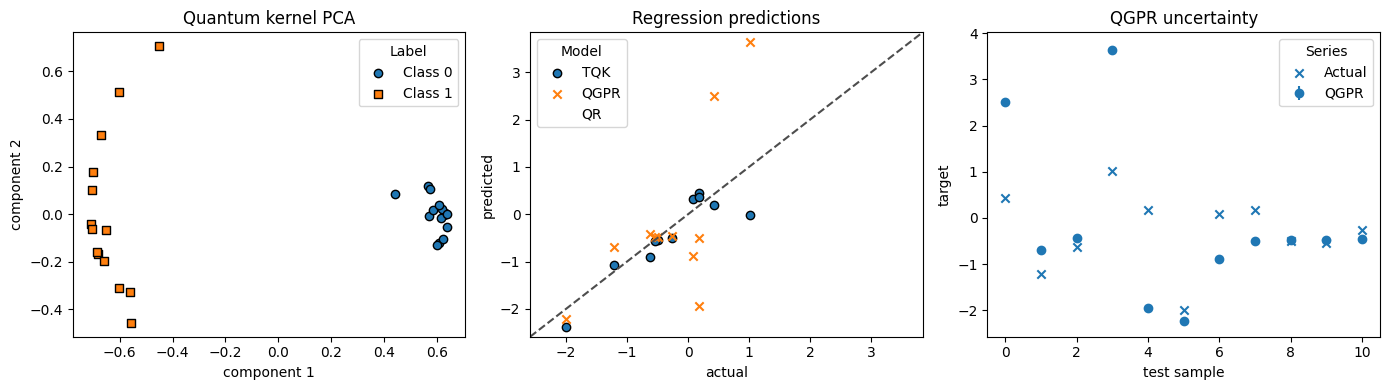

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for cls, name, marker in [(0, "Class 0", "o"), (1, "Class 1", "s")]:
    mask = y_train_cls == cls
    axes[0].scatter(z_train[mask, 0], z_train[mask, 1], marker=marker, label=name, edgecolor="black")
axes[0].set_title("Quantum kernel PCA")
axes[0].set_xlabel("component 1")
axes[0].set_ylabel("component 2")
axes[0].legend(title="Label")

axes[1].scatter(y_test_reg, tqk_pred, label="TQK", edgecolor="black")
axes[1].scatter(y_test_reg, gpr_pred, marker="x", label="QGPR")
axes[1].scatter(y_test_reg, res_reg_pred, marker="s", facecolors="none", label="QR")
low = min(y_test_reg.min(), tqk_pred.min(), gpr_pred.min(), res_reg_pred.min()) - 0.2
high = max(y_test_reg.max(), tqk_pred.max(), gpr_pred.max(), res_reg_pred.max()) + 0.2
axes[1].plot([low, high], [low, high], "--", color="0.3")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_title("Regression predictions")
axes[1].set_xlabel("actual")
axes[1].set_ylabel("predicted")
axes[1].legend(title="Model")

axes[2].errorbar(np.arange(len(gpr_pred)), gpr_pred, yerr=gpr_std, fmt="o", label="QGPR")
axes[2].scatter(np.arange(len(y_test_reg)), y_test_reg, marker="x", label="Actual")
axes[2].set_title("QGPR uncertainty")
axes[2].set_xlabel("test sample")
axes[2].set_ylabel("target")
axes[2].legend(title="Series")
plt.tight_layout()
plt.show()


## Validation block

In [8]:
validation = {
    "classification": classification_results,
    "unsupervised": unsupervised_results,
    "regression": regression_results,
    "passed": bool(
        np.isfinite(z_train).all()
        and set(one_class_pred).issubset({-1, 1})
        and 0.0 <= classification_results["quantum_reservoir_accuracy"] <= 1.0
        and np.isfinite(tqk_pred).all()
        and np.isfinite(gpr_pred).all()
        and np.isfinite(res_reg_pred).all()
    ),
}

print("Validation")
print_section("Classification", classification_results.items())
print_section("Unsupervised", unsupervised_results.items())
print_section("Regression", regression_results.items())
print_section("Passed", [("passed", validation["passed"])])


Validation
Classification
+----------------------------+-------+
| Metric                     | Value |
+----------------------------+-------+
| quantum_reservoir_accuracy | 1     |
+----------------------------+-------+

Unsupervised
+------------------------------------+----------+
| Metric                             | Value    |
+------------------------------------+----------+
| kpca_component_count               | 2        |
| one_class_accuracy_against_class_1 | 0.846154 |
| first_eigenvalue                   | 11.1637  |
+------------------------------------+----------+

Regression
+----------------------------+----------+
| Metric                     | Value    |
+----------------------------+----------+
| trainable_kernel_mse       | 0.145834 |
| quantum_gpr_mse            | 1.59169  |
| quantum_reservoir_mse      | 0.642639 |
| trainable_kernel_alignment | 0.28523  |
| quantum_gpr_mean_std       | 0.031456 |
+----------------------------+----------+

Passed
+--------+-------